In [1]:
!pip install kagglehub

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
from skimage.color import rgb2lab, lab2rgb
import time
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from glob import glob
from sklearn.model_selection import train_test_split

In [7]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [6]:
import kagglehub

kagglehub.dataset_download('aayush9753/image-colorization-dataset')


Using Colab cache for faster access to the 'image-colorization-dataset' dataset.


'/kaggle/input/image-colorization-dataset'

In [8]:
os.listdir("/kaggle/input/image-colorization-dataset")

['data']

In [29]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
LR = 2e-5
EPOCHS = 50
PATIENCE = 15
MIN_DELTA = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
train_color = glob(
    "/kaggle/input/image-colorization-dataset/data/train_color/**/*.[jp][pn]g",
    recursive=True
)

train_black = glob(
    "/kaggle/input/image-colorization-dataset/data/train_black/**/*.[jp][pn]g",
    recursive=True
)

test_color = glob(
    "/kaggle/input/image-colorization-dataset/data/test_color/**/*.[jp][pn]g",
    recursive=True
)

test_black = glob(
    "/kaggle/input/image-colorization-dataset/data/test_black/**/*.[jp][pn]g",
    recursive=True
)

input train black, target train color

In [11]:
val_color, test_color, val_black, test_black = train_test_split(
    test_color,
    test_black,
    test_size=0.5,     #50% test 50% val
    random_state=42,
    shuffle=True
)

In [12]:
class LabDataset(Dataset):
    def __init__(self, black_images, color_images, transform=None):
        self.black_images = black_images
        self.color_images = color_images
        self.transform = transform

    def __len__(self):
        return len(self.black_images)

    def __getitem__(self, idx):
        black = Image.open(self.black_images[idx]).convert("L")
        color = Image.open(self.color_images[idx]).convert("RGB")

        if self.transform:
            black = self.transform(black)
            color = self.transform(color)

        #RGBto LAB
        color = np.array(color)
        lab = rgb2lab(color).astype("float32")

        L  = lab[:, :, 0] / 50.0 - 1.0        # [-1,1]
        ab = lab[:, :, 1:] / 110.0            # [-1,1]

        L  = torch.from_numpy(L).unsqueeze(0)
        ab = torch.from_numpy(ab).permute(2,0,1)

        return L, ab

In [13]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
])

In [14]:
train_dataset = LabDataset(
    black_images=train_black,
    color_images=train_color,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [15]:
test_dataset = LabDataset(
    black_images=test_black,
    color_images=test_color,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [16]:
val_dataset = LabDataset(
    black_images=val_black,
    color_images=val_color,
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [64]:
print('Training set: ', len(train_dataset))
print('Validation set: ', len(val_dataset))
print('Test set: ', len(test_dataset))

Training set:  5000
Validation set:  369
Test set:  370


In [17]:
def lab_to_rgb(L, ab):
    """
    L  : (H, W)       range [0, 1] atau [0, 100]
    ab : (H, W, 2)    range [-1, 1] atau [-128, 128]
    return: RGB (H, W, 3) range [0, 1]
    """

    # ===== Denormalisasi L =====
    if L.max() <= 1.0:
        L = L * 100.0

    # ===== Denormalisasi ab =====
    if np.abs(ab).max() <= 1.0:
        ab = ab * 128.0

    # ===== Gabungkan ke LAB =====
    lab = np.zeros((L.shape[0], L.shape[1], 3))
    lab[:, :, 0] = L
    lab[:, :, 1:] = ab

    # ===== LAB → RGB =====
    rgb = lab2rgb(lab)

    return np.clip(rgb, 0, 1)

In [18]:
def plot_results(model, dataset, start_idx=1, num_samples=5):
    model.eval()
    plt.figure(figsize=(18, num_samples * 4))

    vmax = 0.3  # skala error konsisten

    for i in range(num_samples):
        L, ab = dataset[start_idx + i]

        if L.dim() == 3:          # [1,H,W]
            L = L.unsqueeze(0)    # [B,1,H,W]

        L = L.to(device)

        with torch.no_grad():
            pred_ab = model(L)

        # Data handling
        L_img = L[0, 0].cpu().numpy()                     # BnW
        ab_gt = ab.permute(1, 2, 0).cpu().numpy()         # GT ab
        ab_pd = pred_ab[0].permute(1, 2, 0).cpu().numpy() # Pred ab

        gt_rgb   = lab_to_rgb(L_img, ab_gt)
        pred_rgb = lab_to_rgb(L_img, ab_pd)

        error_map = np.mean(np.abs(gt_rgb - pred_rgb), axis=2)

        row = i * 4

        # ===== BnW Input =====
        plt.subplot(num_samples, 4, row + 1)
        plt.imshow(L_img, cmap="gray")
        plt.title("Input (BnW)")
        plt.axis("off")

        # ===== Ground Truth =====
        plt.subplot(num_samples, 4, row + 2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth")
        plt.axis("off")

        # ===== Predicted =====
        plt.subplot(num_samples, 4, row + 3)
        plt.imshow(pred_rgb)
        plt.title("Predicted")
        plt.axis("off")

        # ===== Error Map =====
        ax = plt.subplot(num_samples, 4, row + 4)
        im = ax.imshow(error_map, cmap="hot", vmin=0, vmax=vmax)
        ax.set_title(f"Error Map\nMean: {error_map.mean():.4f}")
        ax.axis("off")

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Pixel Error")

    plt.tight_layout()
    plt.show()

In [19]:
def train_model(model, save_path):
    best_val_loss = float("inf")
    counter = 0
    best_epoch = 0

    train_losses = []
    val_losses = []

    print("Start training...")
    for epoch in range(EPOCHS):
        # ===== TRAIN =====
        model.train()
        running_train_loss = 0.0

        for input_l, target_ab in train_loader:
            input_l = input_l.to(device)
            target_ab = target_ab.to(device)

            output_ab = model(input_l)
            loss = criterion(output_ab, target_ab)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ===== VALIDATION =====
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for input_l, target_ab in val_loader:
                input_l = input_l.to(device)
                target_ab = target_ab.to(device)

                output_ab = model(input_l)
                loss = criterion(output_ab, target_ab)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # ===== EARLY STOPPING =====
        if avg_val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            counter = 0

            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss
            }, save_path)
        else:
            counter += 1

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"ES Counter: {counter}/{PATIENCE}"
        )

        if counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    print("Training finished.")
    print(f"Best model at epoch {best_epoch} with val loss {best_val_loss:.4f}")

    return train_losses, val_losses, best_epoch, best_val_loss

In [50]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_metrics(model, dataset):
    model.eval()
    psnr_list, ssim_list = [], []

    for i in range(len(dataset)):
        with torch.no_grad():
            L, ab = dataset[i]

            # pastikan L ada batch dim
            if L.dim() == 3:        # [1,H,W]
                L = L.unsqueeze(0)  # [B,1,H,W]

            L = L.to(device)
            pred_ab = model(L)      # [B,2,H,W]

        # =======================
        # Handle L
        # =======================
        L_img = L[0,0].cpu().numpy()   # [H,W]

        # =======================
        # Handle GT ab
        # =======================
        if ab.dim() == 4:              # [B,2,H,W]
            ab_gt = ab[0].permute(1,2,0).cpu().numpy()
        elif ab.dim() == 3:            # [2,H,W]
            ab_gt = ab.permute(1,2,0).cpu().numpy()
        else:                          # [H,W,2]
            ab_gt = ab.cpu().numpy()

        # =======================
        # Predicted ab
        # =======================
        ab_pred = pred_ab[0].permute(1,2,0).cpu().numpy()

        # =======================
        # LAB → RGB
        # =======================
        gt_rgb   = lab_to_rgb(L_img, ab_gt)
        pred_rgb = lab_to_rgb(L_img, ab_pred)

        # =======================
        # Metrics
        # =======================
        psnr_val = psnr(gt_rgb, pred_rgb, data_range=1.0)
        ssim_val = ssim(gt_rgb, pred_rgb, channel_axis=2, data_range=1.0)

        psnr_list.append(psnr_val)
        ssim_list.append(ssim_val)

    return psnr_list, ssim_list

In [21]:
def plot_psnr_ssim_distribution(psnr_list, ssim_list, model_name="Model"):
    psnr = np.array(psnr_list)
    ssim = np.array(ssim_list)

    plt.figure(figsize=(12,5))

    # ===== PSNR Scatter =====
    plt.subplot(1,2,1)
    plt.scatter(range(len(psnr)), psnr)
    plt.axhline(psnr.mean(), linestyle='--', label=f"Mean PSNR = {psnr.mean():.2f}")
    plt.xlabel("Image Index")
    plt.ylabel("PSNR")
    plt.title(f"{model_name} PSNR Distribution")
    plt.legend()

    # ===== SSIM Scatter =====
    plt.subplot(1,2,2)
    plt.scatter(range(len(ssim)), ssim)
    plt.axhline(ssim.mean(), linestyle='--', label=f"Mean SSIM = {ssim.mean():.3f}")
    plt.xlabel("Image Index")
    plt.ylabel("SSIM")
    plt.title(f"{model_name} SSIM Distribution")
    plt.legend()

    plt.tight_layout()
    plt.show()

## VGG UNET

In [26]:
class vgg_unet(nn.Module):
    def __init__(self):
        super().__init__()

        vgg = models.vgg16(pretrained=True)
        vgg.features[0] = nn.Conv2d(1, 64, 3, padding=1)

        feats = list(vgg.features.children())

        # ENCODER
        self.encoder1 = nn.Sequential(*feats[0:5])    # 64
        self.encoder2 = nn.Sequential(*feats[5:10])   # 128
        self.encoder3 = nn.Sequential(*feats[10:17])  # 256
        self.encoder4 = nn.Sequential(*feats[17:24])  # 512
        self.encoder5 = nn.Sequential(*feats[24:31])  # 512

        # CHANNEL ADAPTER (channel alignment for fair comparison)
        self.adapt_e2 = nn.Conv2d(128, 64, 1)
        self.adapt_e3 = nn.Conv2d(256, 128, 1)
        self.adapt_e4 = nn.Conv2d(512, 256, 1)

        # DECODER
        self.decoder4 = self._block(512, 256)
        self.decoder3 = self._block(256 + 256, 128)
        self.decoder2 = self._block(128 + 128, 64)
        self.decoder1 = self._block(64 + 64, 32)

        self.final = nn.Conv2d(32, 2, kernel_size=3, padding=1)
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        )

    def forward(self, x):
        e1 = self.encoder1(x)      # 64
        e2 = self.encoder2(e1)     # 128
        e3 = self.encoder3(e2)     # 256
        e4 = self.encoder4(e3)     # 512
        e5 = self.encoder5(e4)     # 512

        e2 = self.adapt_e2(e2)     # 128 → 64
        e3 = self.adapt_e3(e3)     # 256 → 128
        e4 = self.adapt_e4(e4)     # 512 → 256

        d4 = self.decoder4(e5)
        d3 = self.decoder3(torch.cat([d4, e4], dim=1))
        d2 = self.decoder2(torch.cat([d3, e3], dim=1))
        d1 = self.decoder1(torch.cat([d2, e2], dim=1))

        out = self.final(d1)
        out = self.upsample(out)
        return out


In [30]:
model_vgg_unet = vgg_unet().to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(model_vgg_unet.parameters(), lr=LR)

In [31]:
train_losses, val_losses, best_epoch, best_val_loss = train_model(model_vgg_unet, "vgg_unet.pth")

Start training...
Epoch [1/50] | Train Loss: 0.1137 | Val Loss: 0.0886 | ES Counter: 0/15
Epoch [2/50] | Train Loss: 0.0893 | Val Loss: 0.0849 | ES Counter: 0/15
Epoch [3/50] | Train Loss: 0.0850 | Val Loss: 0.0839 | ES Counter: 0/15
Epoch [4/50] | Train Loss: 0.0839 | Val Loss: 0.0830 | ES Counter: 0/15
Epoch [5/50] | Train Loss: 0.0833 | Val Loss: 0.0820 | ES Counter: 0/15
Epoch [6/50] | Train Loss: 0.0823 | Val Loss: 0.0830 | ES Counter: 1/15
Epoch [7/50] | Train Loss: 0.0818 | Val Loss: 0.0809 | ES Counter: 0/15
Epoch [8/50] | Train Loss: 0.0813 | Val Loss: 0.0806 | ES Counter: 0/15
Epoch [9/50] | Train Loss: 0.0811 | Val Loss: 0.0799 | ES Counter: 0/15
Epoch [10/50] | Train Loss: 0.0804 | Val Loss: 0.0791 | ES Counter: 0/15
Epoch [11/50] | Train Loss: 0.0796 | Val Loss: 0.0790 | ES Counter: 0/15
Epoch [12/50] | Train Loss: 0.0793 | Val Loss: 0.0794 | ES Counter: 1/15
Epoch [13/50] | Train Loss: 0.0787 | Val Loss: 0.0791 | ES Counter: 2/15
Epoch [14/50] | Train Loss: 0.0783 | Val L

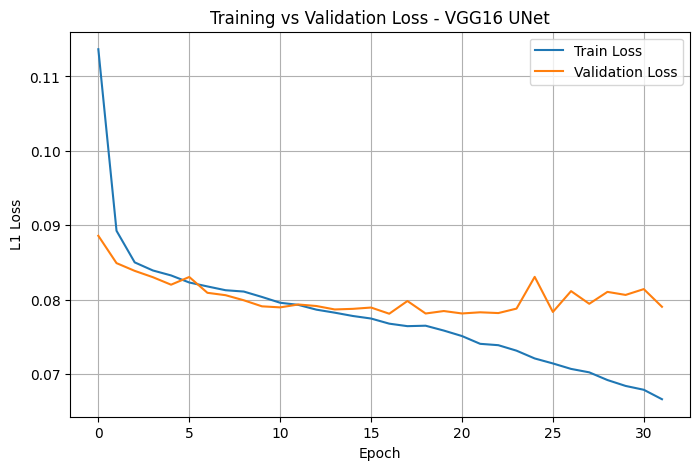

In [32]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training vs Validation Loss - VGG16 UNet")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3120 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2924 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 20165 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 6542 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 34102 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning

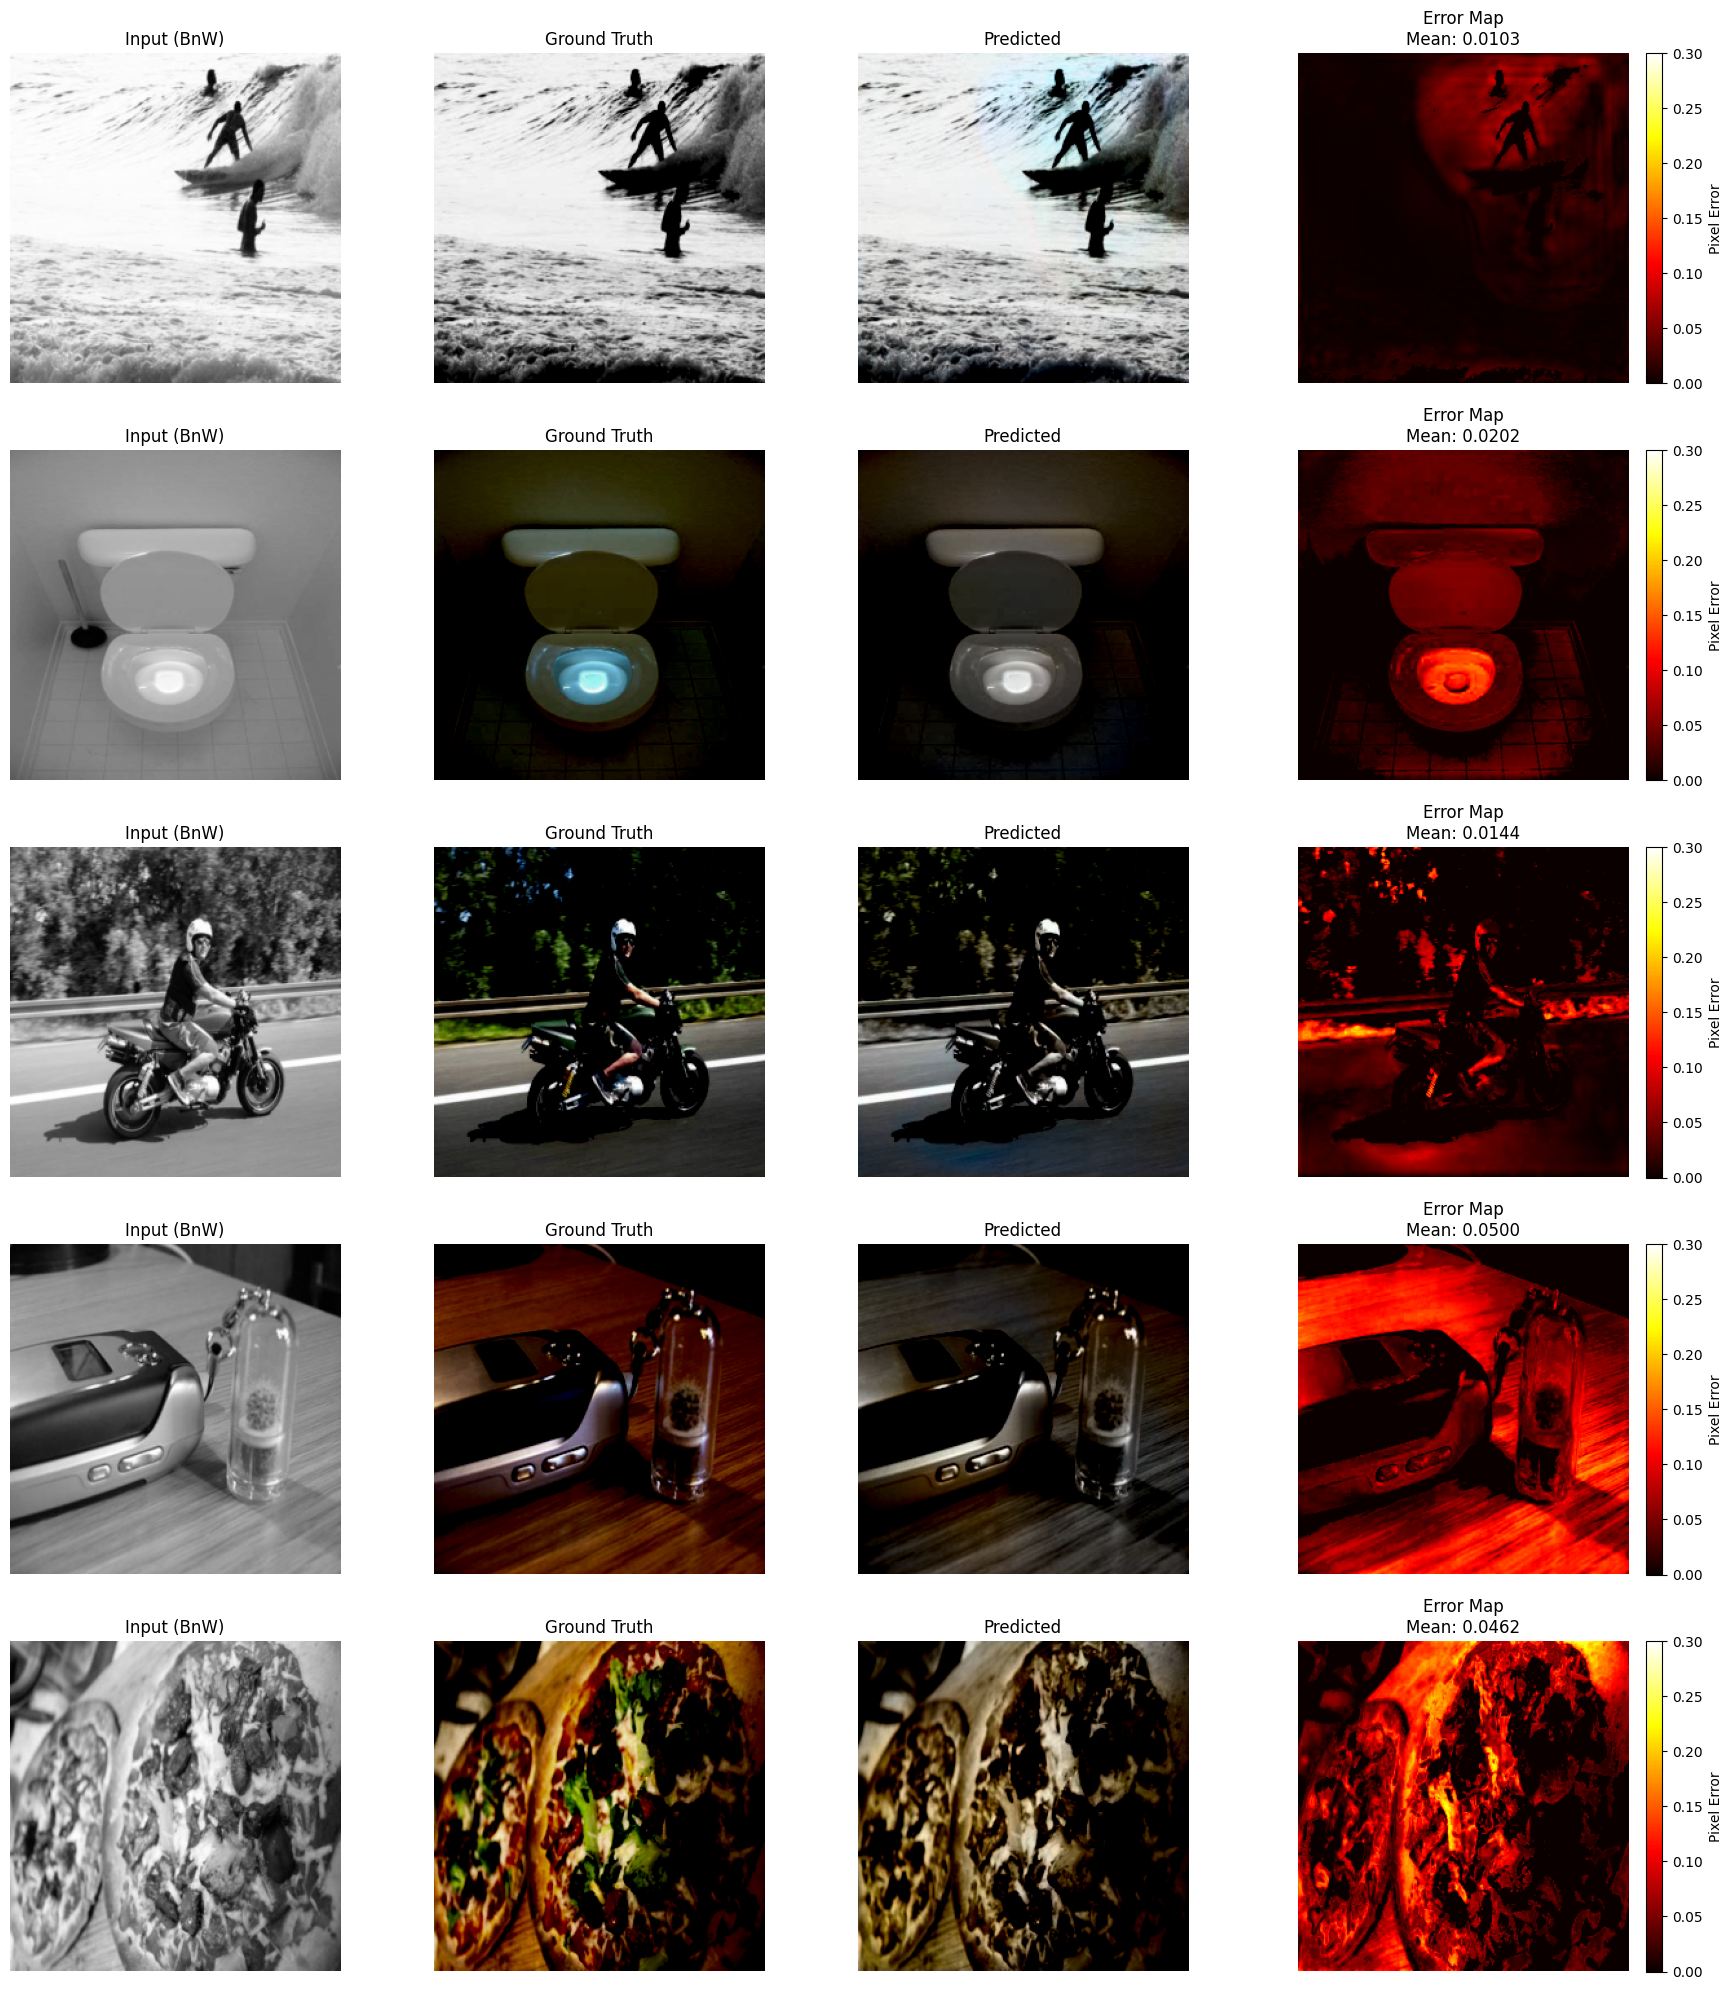

In [35]:
plot_results("model_vgg_unet", start_index=10 test_dataset, 23)

In [ ]:
psnr_list, ssim_list = compute_metrics(model_vgg_unet, test_dataset)

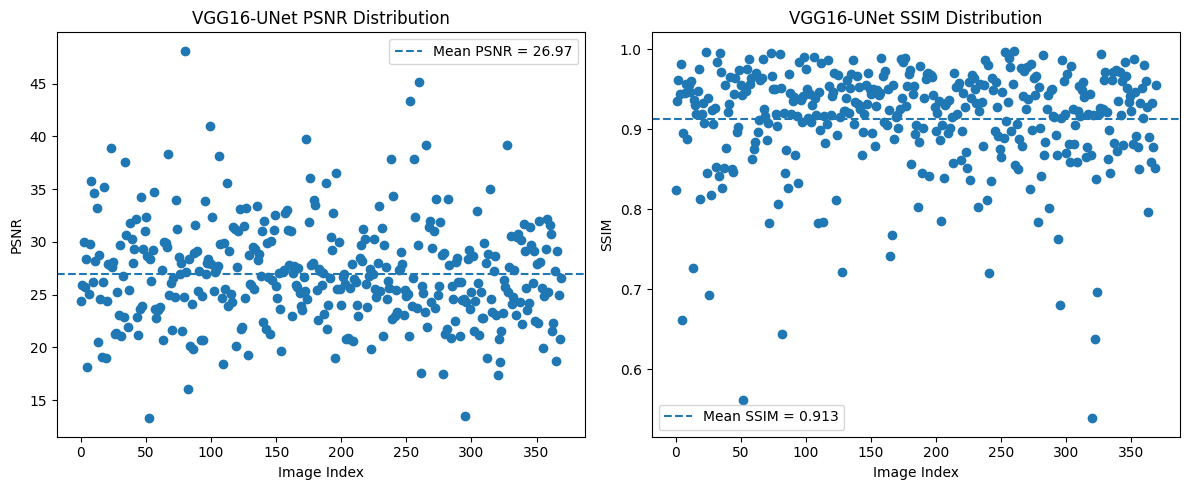

In [54]:
plot_psnr_ssim_distribution(psnr_list, ssim_list, "VGG16-UNet")

## ResNet-UNet

In [37]:
class resnet_unet(nn.Module):
    def __init__(self):
        super(resnet_unet, self).__init__()

        # Encoder: ResNet18 Pretrained
        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.encoder1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.encoder2 = resnet.layer1
        self.encoder3 = resnet.layer2
        self.encoder4 = resnet.layer3
        self.encoder5 = resnet.layer4

        # Decoder
        self.decoder4 = self._block(512, 256)
        self.decoder3 = self._block(256 + 256, 128)
        self.decoder2 = self._block(128 + 128, 64)
        self.decoder1 = self._block(64 + 64, 32)

        self.final = nn.Conv2d(32, 2, kernel_size=3, padding=1)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
        e5 = self.encoder5(e4)

        d4 = self.decoder4(e5)
        d3 = self.decoder3(torch.cat([d4, e4], dim=1))
        d2 = self.decoder2(torch.cat([d3, e3], dim=1))
        d1 = self.decoder1(torch.cat([d2, e2], dim=1))

        out = self.final(d1)
        out = self.upsample(out)

        return out

In [38]:
model_resnet_unet = resnet_unet().to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(model_resnet_unet.parameters(), lr=LR)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


In [39]:
train_losses, val_losses, best_epoch, best_val_loss = train_model(model_resnet_unet, "resnet_unet.pth")

Start training...
Epoch [1/50] | Train Loss: 0.1423 | Val Loss: 0.0926 | ES Counter: 0/15
Epoch [2/50] | Train Loss: 0.0888 | Val Loss: 0.0859 | ES Counter: 0/15
Epoch [3/50] | Train Loss: 0.0843 | Val Loss: 0.0829 | ES Counter: 0/15
Epoch [4/50] | Train Loss: 0.0819 | Val Loss: 0.0819 | ES Counter: 0/15
Epoch [5/50] | Train Loss: 0.0804 | Val Loss: 0.0805 | ES Counter: 0/15
Epoch [6/50] | Train Loss: 0.0787 | Val Loss: 0.0800 | ES Counter: 0/15
Epoch [7/50] | Train Loss: 0.0773 | Val Loss: 0.0811 | ES Counter: 1/15
Epoch [8/50] | Train Loss: 0.0754 | Val Loss: 0.0805 | ES Counter: 2/15
Epoch [9/50] | Train Loss: 0.0740 | Val Loss: 0.0809 | ES Counter: 3/15
Epoch [10/50] | Train Loss: 0.0721 | Val Loss: 0.0803 | ES Counter: 4/15
Epoch [11/50] | Train Loss: 0.0707 | Val Loss: 0.0806 | ES Counter: 5/15
Epoch [12/50] | Train Loss: 0.0692 | Val Loss: 0.0828 | ES Counter: 6/15
Epoch [13/50] | Train Loss: 0.0679 | Val Loss: 0.0807 | ES Counter: 7/15
Epoch [14/50] | Train Loss: 0.0667 | Val L

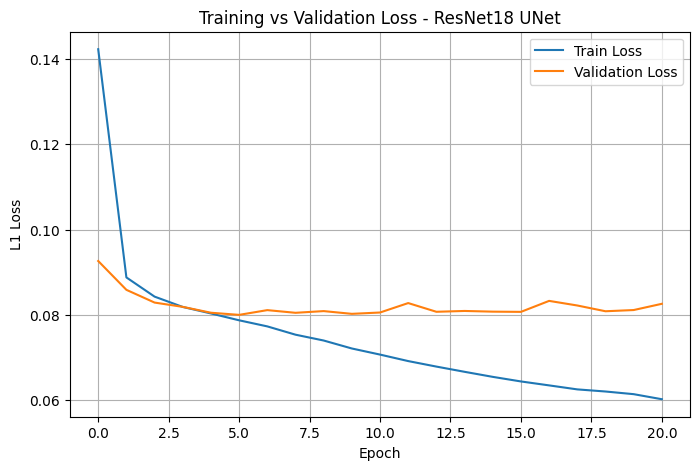

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training vs Validation Loss - ResNet18 UNet")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3120 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2830 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 20165 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 8618 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 34102 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)
/tmp/ipython-input-1868641465.py:22: UserWarning

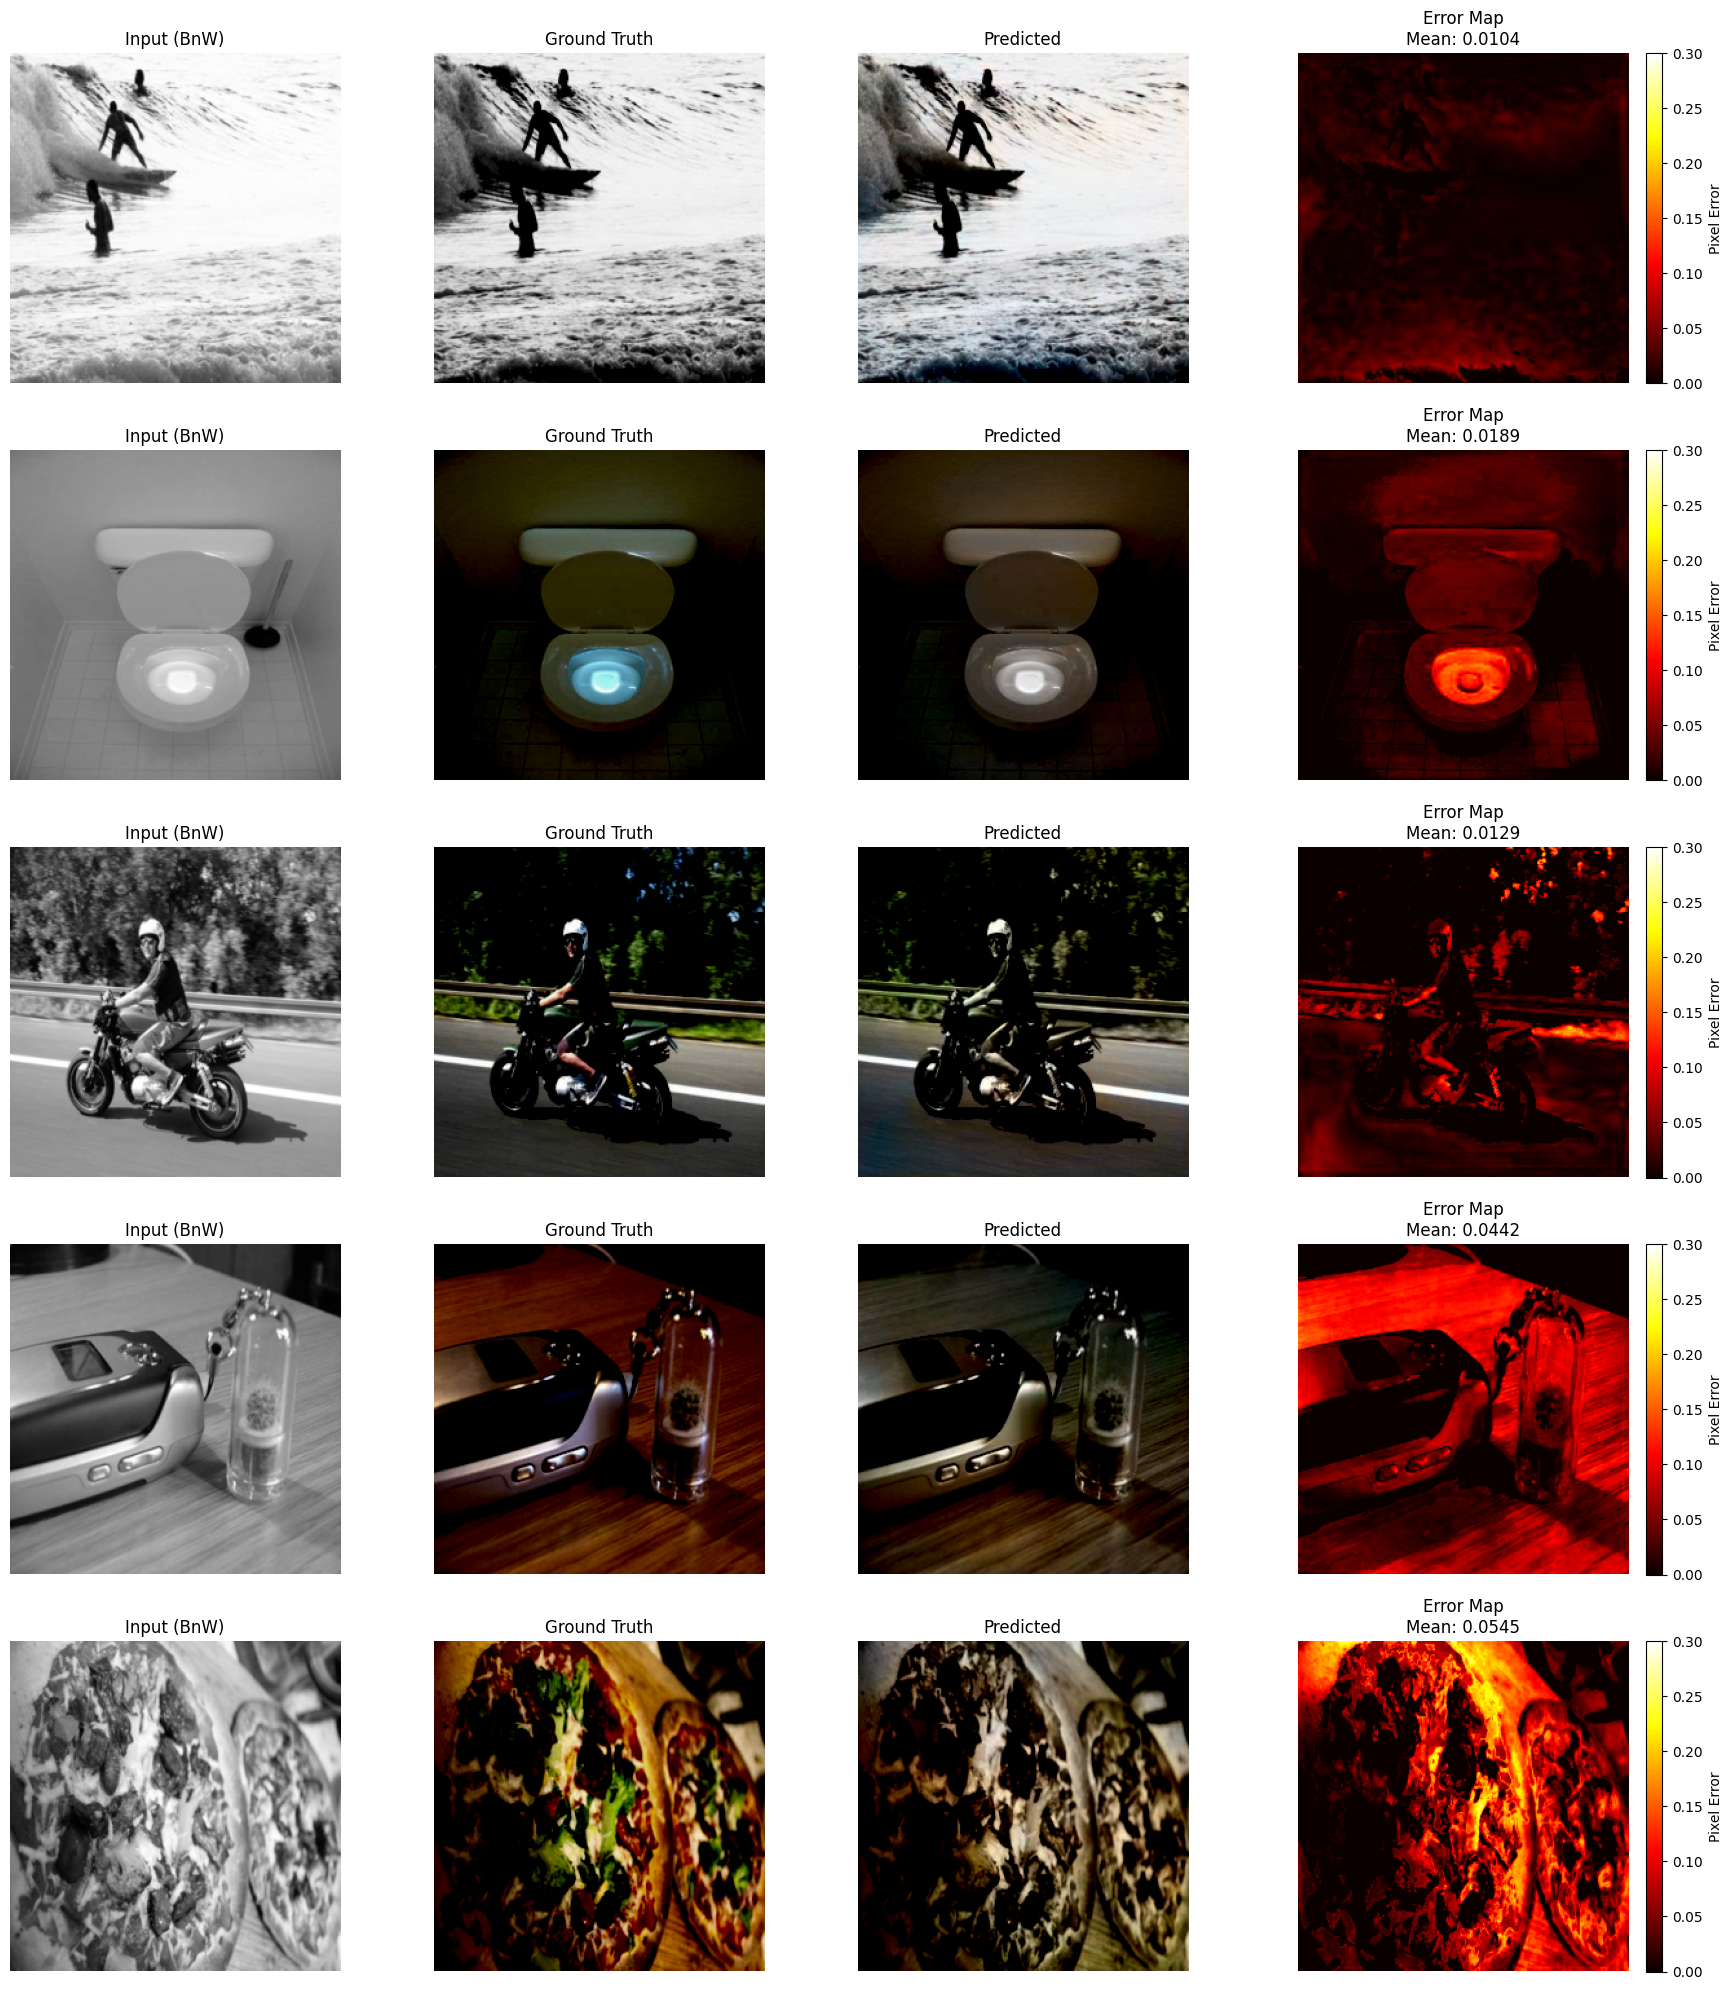

In [43]:
plot_results(model_resnet_unet, test_dataset, 23)

In [ ]:
psnr_list, ssim_list = compute_metrics(model_resnet_unet, test_dataset)

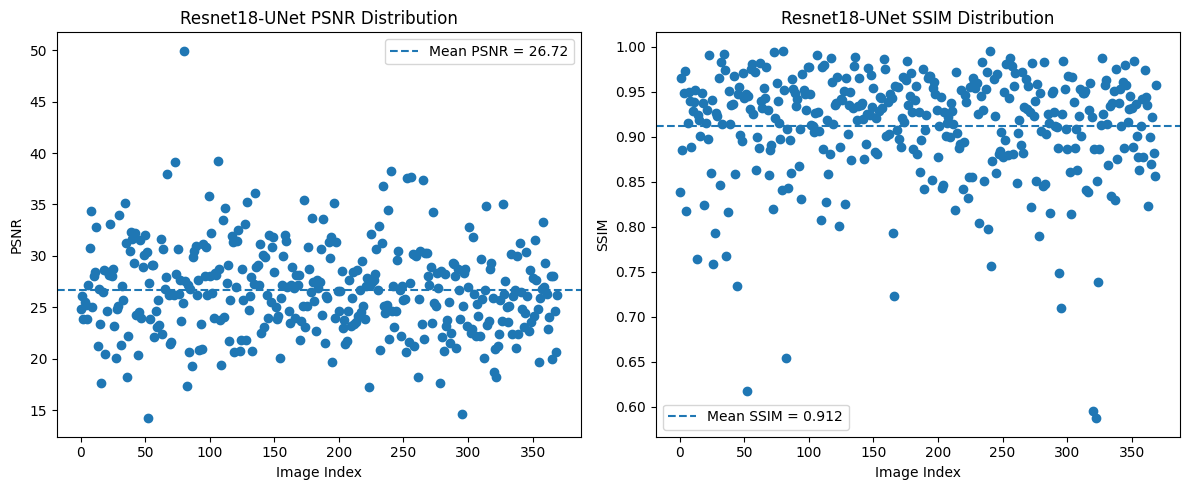

In [52]:
plot_psnr_ssim_distribution(psnr_list, ssim_list, "Resnet18-UNet")

In [75]:
models_dict = {
    "VGG-UNet": vgg_unet(),
    "ResNet-UNet": resnet_unet()
}

for name, model in models_dict.items():
    model.to(device)
    model.eval()  # mode inference

# Dummy input
batch_size = 1
channels = 1
height = 256
width = 256
x = torch.randn(batch_size, channels, height, width).to(device)


if device.type == 'cuda':
    for _ in range(10):
        with torch.no_grad():
            _ = model(x)

def measure_inference(model, x, runs=100):
    times = []
    for _ in range(runs):
        if device.type == 'cuda':
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()
            with torch.no_grad():
                _ = model(x)
            end_event.record()
            torch.cuda.synchronize()
            times.append(start_event.elapsed_time(end_event))  # ms
        else:
            start_time = time.time()
            with torch.no_grad():
                _ = model(x)
            times.append((time.time() - start_time) * 1000)  # ms
    avg_time = sum(times) / len(times)
    return avg_time

# Measure & Compare
for name, model in models_dict.items():
    avg_time = measure_inference(model, x, runs=100)
    print(f"{name} - Average Inference Time per image: {avg_time:.2f} ms")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
 

VGG-UNet - Average Inference Time per image: 9.39 ms
ResNet-UNet - Average Inference Time per image: 3.74 ms
